In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# files = [
#     "loans_master.csv",
#     "loan_performance.csv",
#     "customer_bureau.csv",
#     "loan_enquiry_bureau.csv",
#     "credit_card_behavior.csv",
#     "collateral_assets.csv",
#     "monthly_emi_track.csv",
#     "payment_history.csv",
#     "branch_region_economy.csv"
# ]
# dataframes = {}

# for file in files:
#     df_name = file.replace(".csv", "")
#     dataframes[df_name] = pd.read_csv(file)
    

# print(dataframes.keys())
# "C:\Users\Admin\OneDrive\Desktop\EDA\branch_region_economy.csv"

In [3]:
# LOADING ALL THE DATASETS 
Loan_Applications=pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\EDA\loans_master.csv")
Customer_Bureau=pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\EDA\customer_bureau.csv")
Payment_History=pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\EDA\payment_history.csv")
Loan_Performance=pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\EDA\loan_performance.csv")
EMI_Tracking=pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\EDA\monthly_emi_track.csv")
Collateral=pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\EDA\collateral_assets.csv")
Branch_Economy=pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\EDA\branch_region_economy.csv")
Credit_Cards=pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\EDA\credit_card_behavior.csv")
Enquiry_Bureau=pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\EDA\loan_enquiry_bureau.csv")

In [4]:
files=[
      Loan_Applications,Customer_Bureau, Payment_History ,  Loan_Performance , EMI_Tracking , Collateral , Branch_Economy , Credit_Cards , Enquiry_Bureau
    ]

In [5]:
for file in files:
    size_mb = file.memory_usage(deep=True).sum() / (1024 * 1024)
    print(f"{size_mb:.2f} MB")

548.12 MB
544.89 MB
295.64 MB
245.73 MB
419.35 MB
368.30 MB
351.33 MB
302.30 MB
491.03 MB


In [6]:
# MERGING THE ALL TABLES
df = Loan_Applications.merge(Customer_Bureau,on='loan_id',how='left').merge(Payment_History,on='loan_id',how='left').merge(Loan_Performance,on='loan_id',how='left').merge(EMI_Tracking,on='loan_id',how='left').merge(Collateral,on='loan_id',how='left').merge(Branch_Economy,on='loan_id',how='left').merge(Credit_Cards,on='loan_id',how='left').merge(Enquiry_Bureau,on='loan_id',how='left')

In [7]:
df.shape

(2000000, 182)

In [8]:
size_before_downcasting = df.memory_usage(deep=True).sum()/(1024**2)
print(f"{size_before_downcasting:.2f} MB")

3276.77 MB


In [9]:
#Downcasting

In [10]:
# Integer columns: int64 -> int8/int16/int32
int_cols = df.select_dtypes(include=['int64']).columns

df[int_cols] = df[int_cols].apply(
    pd.to_numeric,
    downcast='integer'
)

In [11]:
# Float columns: float64 -> float32
float_cols = df.select_dtypes(include=['float64']).columns

df[float_cols] = df[float_cols].apply(
    pd.to_numeric,
    downcast='float'
)

In [12]:
# Select all object and string columns and convert them to category type
# to reduce memory usage by storing repeated values as encoded categories
obj_cols = df.select_dtypes(include=['object', 'string']).columns

for col in obj_cols:
    df[col] = df[col].astype('category')

In [13]:
size_after_downcasting = df.memory_usage(deep=True).sum()/(1024**2)
print(f"{size_after_downcasting:.2f} MB")

1145.02 MB


In [14]:
## Save the DataFrame as a Parquet file

In [15]:
!pip install pyarrow

In [16]:
!pip install fastparquet

In [17]:
import pyarrow

In [18]:
# Save the DataFrame as a Parquet file
df.to_parquet("loan_data.parquet", index=False)

In [19]:
df = pd.read_parquet("loan_data.parquet") 

In [20]:
size_after_parquet = df.memory_usage(deep=True).sum()/(1024**2)
print(f"{size_after_parquet:.2f} MB")

1144.63 MB


In [21]:
# (b)
# Join all nine tables on loan_id using sequential left merges. After every individual join, assert that the running row count equals 2,000,000. 
#     Report the number of orphan records found, if any, and explain what orphan records indicate about data integrity.



In [22]:
# Start with the master table
merge_df = Loan_Applications.copy()

tables = [
    Customer_Bureau,
    Payment_History,
    Loan_Performance,
    EMI_Tracking,
    Collateral,
    Branch_Economy,
    Credit_Cards,
    Enquiry_Bureau
]

table_names = [
    "Customer_Bureau",
    "Payment_History",
    "Loan_Performance",
    "EMI_Tracking",
    "Collateral",
    "Branch_Economy",
    "Credit_Cards",
    "Enquiry_Bureau"
]

for name, table in zip(table_names, tables):

    merge_df = merge_df.merge(
        table,
        on="loan_id",
        how="left"
    )

    current_rows = len(merge_df)

    print(f"After joining {name}: {current_rows:,} rows")

    assert current_rows == 2000000, \
        f"Row count changed after joining {name}"

After joining Customer_Bureau: 2,000,000 rows
After joining Payment_History: 2,000,000 rows
After joining Loan_Performance: 2,000,000 rows
After joining EMI_Tracking: 2,000,000 rows
After joining Collateral: 2,000,000 rows
After joining Branch_Economy: 2,000,000 rows
After joining Credit_Cards: 2,000,000 rows
After joining Enquiry_Bureau: 2,000,000 rows


In [23]:
# ==========================================
# Orphan Record Analysis
# ==========================================

total_orphans = 0

for name, table in zip(table_names, tables):

    orphan_count = (
        ~table["loan_id"].isin(
            Loan_Applications["loan_id"]
        )
    ).sum()

    total_orphans += orphan_count

    print(f"{name}: {orphan_count:,} orphan records")

print(f"\nTotal Orphan Records: {total_orphans:,}")

Customer_Bureau: 0 orphan records
Payment_History: 0 orphan records
Loan_Performance: 0 orphan records
EMI_Tracking: 0 orphan records
Collateral: 0 orphan records
Branch_Economy: 0 orphan records
Credit_Cards: 0 orphan records
Enquiry_Bureau: 0 orphan records

Total Orphan Records: 0


In [24]:
# Orphan records are records in child tables whose loan_id
# does not exist in the parent table (Loan_Applications).

# These records indicate referential integrity issues and may
# result from missing master records, incorrect foreign keys,
# or ETL/data ingestion problems.

# A count of zero orphan records indicates good data integrity,
# while non-zero counts suggest inconsistencies that should be
# investigated before analysis

In [25]:
# (c)
# The dataset contains eight deliberately injected data quality issues across multiple columns.
# Identify all eight, create a binary dirty_flag column to mark affected rows, and for each issue state:
# the column affected, the approximate count of dirty records, why the value is invalid, and the imputation strategy you applied.

In [26]:
# Check data types and missing values

In [27]:
df.columns.tolist()

['loan_id',
 'issue_date',
 'issue_year',
 'issue_month',
 'loan_amnt_inr',
 'funded_amnt_inr',
 'loan_term_months',
 'int_rate_pct',
 'installment_inr',
 'annual_installment_inr',
 'grade',
 'sub_grade',
 'loan_purpose',
 'state_code',
 'region',
 'urban_index',
 'application_type',
 'pymnt_plan',
 'hardship_flag',
 'initial_list_status',
 'disbursement_method',
 'verification_status',
 'rbi_repo_rate_pct',
 'gdp_growth_pct',
 'cpi_inflation_pct',
 'rate_spread_pct',
 'real_interest_rate_pct',
 'customer_id',
 'age',
 'gender',
 'emp_title',
 'emp_length_years',
 'home_ownership',
 'annual_inc_inr',
 'dti_pct',
 'cibil_score',
 'earliest_cr_line',
 'credit_hist_years',
 'revol_bal_inr',
 'revol_util_pct',
 'open_acc',
 'total_acc',
 'mort_acc',
 'pub_rec',
 'delinq_2yrs',
 'num_inq_last6m',
 'num_inq_last12m',
 'pct_tl_nvr_dlq',
 'total_rev_hi_lim_inr',
 'bc_util_pct',
 'il_util_pct',
 'all_util_pct',
 'avg_cur_bal_inr',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'num_tl_o

In [28]:
# Check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Columns: 182 entries, loan_id to tat_within_sla_flag
dtypes: category(45), float32(55), float64(29), int16(3), int32(1), int8(49)
memory usage: 1.1 GB


In [29]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
loan_id,2000000,2000000,LN000000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
issue_date,2000000,180,Nov-2022,15199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
issue_year,2000000.0,NaN,NaN,NaN,2017.929101,4.13879,2010.0,2015.0,2018.0,2022.0,2024.0
issue_month,2000000.0,NaN,NaN,NaN,6.500045,3.452964,1.0,4.0,6.0,10.0,12.0
loan_amnt_inr,2000000.0,NaN,NaN,NaN,150338.875,133454.03125,50000.0,64541.0,109172.0,184666.0,5000000.0
...,...,...,...,...,...,...,...,...,...,...,...
policy_deviation_flag,2000000.0,NaN,NaN,NaN,0.326736,0.46902,0.0,0.0,0.0,1.0,1.0
policy_override_flag,2000000.0,NaN,NaN,NaN,0.050029,0.218005,0.0,0.0,0.0,0.0,1.0
sanctioned_amount_inr,2000000.0,NaN,NaN,NaN,139054.453125,123707.023438,42500.0,59580.0,100876.0,170857.0,4927587.0
disbursed_amount_inr,2000000.0,NaN,NaN,NaN,133497.625,118850.421875,39117.0,57184.0,96798.0,164024.25,4743056.0


In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
issue_year,2000000.0,2017.929101,4.138790,2010.0,2015.0,2018.0,2022.00,2024.0
issue_month,2000000.0,6.500045,3.452964,1.0,4.0,6.0,10.00,12.0
loan_amnt_inr,2000000.0,150338.875000,133454.031250,50000.0,64541.0,109172.0,184666.00,5000000.0
funded_amnt_inr,2000000.0,141323.250000,125671.429688,44000.0,60587.0,102546.0,173600.00,4810737.0
loan_term_months,2000000.0,45.129150,15.748448,12.0,36.0,48.0,60.00,84.0
...,...,...,...,...,...,...,...,...
policy_deviation_flag,2000000.0,0.326736,0.469020,0.0,0.0,0.0,1.00,1.0
policy_override_flag,2000000.0,0.050029,0.218005,0.0,0.0,0.0,0.00,1.0
sanctioned_amount_inr,2000000.0,139054.453125,123707.023438,42500.0,59580.0,100876.0,170857.00,4927587.0
disbursed_amount_inr,2000000.0,133497.625000,118850.421875,39117.0,57184.0,96798.0,164024.25,4743056.0


In [31]:
df.isnull().sum().sort_values(ascending = False)

vehicle_type              1879789
property_type             1679672
property_city_tier        1679672
mths_since_last_record    1598332
ltv_ratio_pct             1472196
                           ...   
policy_deviation_flag           0
policy_override_flag            0
sanctioned_amount_inr           0
disbursed_amount_inr            0
tat_within_sla_flag             0
Length: 182, dtype: int64

In [32]:
cols_with_nulls = df.columns[df.isnull().sum() > 0].tolist()
print(cols_with_nulls)

['emp_length_years', 'annual_inc_inr', 'revol_util_pct', 'mort_acc', 'pub_rec', 'delinq_2yrs', 'num_inq_last6m', 'pct_tl_nvr_dlq', 'bc_util_pct', 'il_util_pct', 'all_util_pct', 'avg_cur_bal_inr', 'mths_since_last_delinq', 'mths_since_last_record', 'last_pymnt_amnt_inr', 'collection_recovery_fee', 'cibil_score_band', 'avg_payment_delay_days', 'emi_bank_name', 'pdc_count', 'collateral_type', 'ltv_ratio_pct', 'property_type', 'property_city_tier', 'vehicle_type', 'valuation_agency', 'charge_type', 'collateral_score', 'loan_officer_exp_years', 'branch_sanction_rate', 'cash_advance_inr', 'primary_card_type', 'primary_cc_bank', 'top_spend_category', 'cc_payment_score', 'income_doc_type', 'field_verification_status', 'processing_days']


In [33]:
# filter only columns with nulls
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]  # filter only columns with nulls
print(null_counts)

emp_length_years              180539
annual_inc_inr                 40066
revol_util_pct                140097
mort_acc                      260330
pub_rec                       118951
delinq_2yrs                   100207
num_inq_last6m                 80130
pct_tl_nvr_dlq                 59892
bc_util_pct                   160397
il_util_pct                   200167
all_util_pct                   79649
avg_cur_bal_inr               100027
mths_since_last_delinq       1098640
mths_since_last_record       1598332
last_pymnt_amnt_inr           119889
collection_recovery_fee       120086
cibil_score_band                  10
avg_payment_delay_days        120364
emi_bank_name                 120236
pdc_count                     120057
collateral_type              1258896
ltv_ratio_pct                1472196
property_type                1679672
property_city_tier           1679672
vehicle_type                 1879789
valuation_agency             1370048
charge_type                  1258896
c

In [34]:
# Check categorical columns
#got to know which particular category count in particular column
for col in df.select_dtypes(include=['object','category']).columns:
    print("\n", col)
    print(df[col].value_counts(dropna=False).head(5))


 loan_id
loan_id
LN000000001    1
LN000000002    1
LN000000003    1
LN000000004    1
LN000000005    1
Name: count, dtype: int64

 issue_date
issue_date
Nov-2022    15199
May-2022    15175
Jun-2022    15116
Feb-2022    15107
Sep-2022    15049
Name: count, dtype: int64

 grade
grade
B    440088
C    398758
A    360837
D    319253
E    240030
Name: count, dtype: int64

 sub_grade
sub_grade
B2    88326
B3    88034
B5    88023
B4    87954
B1    87751
Name: count, dtype: int64

 loan_purpose
loan_purpose
debt_consolidation    559418
home_improvement      240263
medical               180524
small_business        180481
education             139239
Name: count, dtype: int64

 state_code
state_code
MH    258992
DL    222694
KA    184602
TN    167054
UP    148346
Name: count, dtype: int64

 region
region
North      666948
South      592610
West       389054
East       221968
Central     92521
Name: count, dtype: int64

 application_type
application_type
Individual    1759831
Joint App      2401

In [35]:
#checking any duplicate loan_id is there
(df['loan_id'].value_counts() > 1).sum()

np.int64(0)

In [36]:
# Create dirty_flag

In [37]:
df['dirty_flag'] = 0
#mark row as dirty whenever an issue is found.

# Store issue summary
issues = []

In [38]:
# issue :- Invalid age
#age < 18 or > 100
invalid_age = (df['age'] < 18) | (df['age'] > 100)

df.loc[invalid_age, 'dirty_flag'] = 1
if invalid_age.sum() > 0:
        issues.append({
            'column': 'age',
            'count': invalid_age.sum(),
            'reason': 'Age outside valid range (18-100)',
            'imputation': 'Median age'
        })
df.loc[invalid_age, 'age'] = df.loc[invalid_age, 'age'].abs()
df.loc[invalid_age, 'dirty_flag'] = 1

In [39]:
#checks Negative Income
invalid_income = (df['loan_amnt_inr']<0)

if invalid_income.sum() > 0 :
    issues.append({
        "column":"'loan_amnt_inr'",
        "dirty_count": int(invalid_income.sum()),
        "reason" : "Age outside valid range (above 0 , it should be -ve)",
        "imputation" : "Absolute value (flip sign)"
    })
df.loc[invalid_income, 'loan_amnt_inr'] = df.loc[invalid_income, 'loan_amnt_inr'].abs()
df.loc[invalid_income, 'dirty_flag'] = 1

In [40]:
(df['loan_amnt_inr']<0).value_counts()

loan_amnt_inr
False    2000000
Name: count, dtype: int64

In [41]:
# Issue 2: Interest rate > 100%
invalid_int_rate = df['int_rate_pct'] > 100
if invalid_int_rate.sum()>0:
    issues.append({
        "column":"'int_rate_pct'",
        "dirty_count": int(invalid_int_rate.sum()),
        "reason" : "Interest rate > 100% is unrealistic for personal loans",
        "imputation" : "Divide by 100 (likely decimal error)"
                  })
df.loc[invalid_int_rate, 'int_rate_pct'] = df.loc[invalid_int_rate, 'int_rate_pct'] / 100
df.loc[invalid_int_rate, 'dirty_flag'] = 1


# int_rate_pct
# False    2000000
# Name: count, dtype: int64

In [42]:
(df['cibil_score'] < 300).value_counts()


cibil_score
False    2000000
Name: count, dtype: int64

In [43]:
# Issue 3: CIBIL score out of valid range (300–900)
invali_CIBIL = (df['cibil_score'] < 300) | (df['cibil_score'] > 900)
if invali_CIBIL.sum()>0:
    issues.append({  
        "column":"cibil_score",
        "dirty_count": int(invalid_CIBIL.sum()),
        "reason" : "CIBIL can not be less then 300 and greater then 900",
        "imputation" : "Replace with median valid CIBIL score"})

median_cibil = df.loc[
    (df['cibil_score'] >= 300) &
    (df['cibil_score'] <= 900),
    'cibil_score'
].median()

df.loc[invali_CIBIL, 'cibil_score'] = median_cibil
df.loc[invali_CIBIL, 'dirty_flag'] = 1


In [44]:
# Issue 5: DTI > 100%
# DTI stands for Debt-to-Income ratio -- How much of a person’s monthly income goes toward paying debts.

invalid_DTI = df['dti_pct'] > 100

if invalid_DTI.sum() > 0:

    issues.append({
        'Column': 'dti_pct',
        'Count': invalid_DTI.sum(),
        'Why Invalid': 'DTI > 100% indicates debt exceeds income, which is unrealistic',
        'Strategy': 'Cap values at 99th percentile of valid data'
    })

    cap5 = df.loc[df['dti_pct'] <= 100, 'dti_pct'].quantile(0.99)

    df.loc[invalid_DTI, 'dti_pct'] = cap5
    df.loc[invalid_DTI, 'dirty_flag'] = 1

In [45]:
# Issue 6: Employment length < 0
invali_emp_length = df['emp_length_years'] < 0
if invali_emp_length.sum()>0:
    issues.append({
        'Column': 'emp_length_years',
        'Count': invali_emp_length.sum(),
        'Why Invalid': 'Employment years cannot be negative',
        'Strategy': 'Set to 0 (unemployed / fresher)'  
    })
df.loc[invali_emp_length, 'emp_length_years'] = 0
df.loc[invali_emp_length, 'dirty_flag'] = 1


In [46]:
#Issue 7: Issue 7: Revolver utilisation > 100%> 100%
# Revolver utilization = Percentage of credit card limit that is being used at a given time.
# Revolver Utilization (%) = (Outstanding Credit Balance / Total Credit Limit) × 100
invalid_Revolver_utilization = df['revol_util_pct'] > 100
if invalid_Revolver_utilization.sum() > 0:
    issues.append({
        'Column': 'revol_util_pct',
        'Count': invalid_Revolver_utilization.sum(),
        'Why Invalid': 'Utilisation > 100% is impossible',
        'Strategy': 'Clip to 100'   
        
    })
df.loc[invalid_Revolver_utilization, 'revol_util_pct'] = 100
df.loc[invalid_Revolver_utilization, 'dirty_flag'] = 1

In [47]:
# Issue 8: Duplicate loan_ids
duplicates = df.duplicated(subset='loan_id', keep='first')
if duplicates.sum()>0:
    issues.append({
        'Column': 'revol_util_pct',
        'Count': duplicates.sum(),
        'Why Invalid': 'Each loan must be unique — duplicates inflate counts',
        'Strategy': 'Keep first occurrence, drop duplicates' 
    })
df.loc[duplicates, 'dirty_flag'] = 1
df = df[~duplicates].reset_index(drop=True)

In [48]:
print('=== Data Quality Issues Found ===')
print(pd.DataFrame(issues).to_string(index=False))
print(f'\nTotal dirty rows flagged: {df["dirty_flag"].sum():,}')

=== Data Quality Issues Found ===
Empty DataFrame
Columns: []
Index: []

Total dirty rows flagged: 0


In [49]:
# (d)
# Classify the missing-value pattern for each high-missing column (mths_since_last_delinq, mort_acc, emp_length_years, il_util_pct) as MCAR, MAR, or MNAR.
# Justify each classification using either Little's MCAR test output or domain reasoning. Apply the correct imputation strategy and
# verify with .isnull().sum() before and after.



In [50]:
### Q1(d) – Missing Value Pattern: MCAR / MAR / MNAR + Imputation [6 Marks]

In [51]:
high_missing_cols = ['mths_since_last_delinq', 'mort_acc', 'emp_length_years', 'il_util_pct']

print('Missing counts BEFORE imputation:')
print(df[high_missing_cols].isnull().sum())

Missing counts BEFORE imputation:
mths_since_last_delinq    1098640
mort_acc                   260330
emp_length_years           180539
il_util_pct                200167
dtype: int64


In [52]:
# Missing percentage
df[high_missing_cols].isnull().mean() * 100

mths_since_last_delinq    54.93200
mort_acc                  13.01650
emp_length_years           9.02695
il_util_pct               10.00835
dtype: float64

In [53]:
# ── Classification & Justification ──────────────────────────────────────────
# mths_since_last_delinq → MNAR
#   Missing BECAUSE the borrower has never been delinquent — the missingness
#   is directly related to the value (0 delinquencies = no 'months since' to record).
#   Strategy: impute with 999 (a sentinel meaning 'no delinquency ever').
df['mths_since_last_delinq'] = df['mths_since_last_delinq'].fillna(999)

In [54]:
# mort_acc → MAR
#   Missing correlates with home_ownership (renters have fewer mortgage accounts).
#   Strategy: impute with median within each home_ownership group.
df['mort_acc'] = df.groupby('home_ownership')['mort_acc'].transform(
    lambda x: x.fillna(x.median()))

In [55]:
# emp_length_years → MAR
#   Missing correlates with emp_title (e.g., self-employed, student may skip).
#   Strategy: median imputation by emp_title group.
df['emp_length_years'] = df.groupby('emp_title')['emp_length_years'].transform(
    lambda x: x.fillna(x.median()))
# Remaining NaNs (if any emp_title group has all-NaN) → global median
df['emp_length_years'] = df['emp_length_years'].fillna(df['emp_length_years'].median())

In [56]:
# il_util_pct → MCAR
#   No systematic pattern; borrowers without installment credit lines simply
#   have no utilisation to report. Missing at random across all groups.
#   Strategy: median imputation.
df['il_util_pct'] = df['il_util_pct'].fillna(df['il_util_pct'].median())

In [57]:
print('\nMissing counts AFTER imputation:')
print(df[high_missing_cols].isnull().sum())


Missing counts AFTER imputation:
mths_since_last_delinq    0
mort_acc                  0
emp_length_years          0
il_util_pct               0
dtype: int64


In [58]:
# (e)
# Apply winsorisation at the 1st and 99th percentile to the six most skewed numeric columns. 
# Present a before-and-after comparison of mean, standard deviation, and max for each column in a summary table.

In [59]:
# Winsorisation means:

# Replace extreme values with boundary values (not remove them)
# Values below 1st percentile → set to 1st percentile
# Values above 99th percentile → set to 99th percentile

In [60]:
# Step 1: select numeric columns
num_cols = df.select_dtypes(include='number').columns

# Step 2: find skewness
skewness = df[num_cols].skew().abs()

# Step 3: pick top 6 skewed columns
top6 = skewness.sort_values(ascending=False).head(6).index

# Step 4: store before stats
before = df[top6].agg(['mean', 'std', 'max']).T
before.columns = ['mean_before', 'std_before', 'max_before']
print(before)

                         mean_before    std_before  max_before
npa_flag                    0.000008      0.002739        1.00
collections_12mths_fee     32.366464    560.070667   312618.52
collection_recovery_fee   130.709817   2061.435988  1035421.73
recoveries_inr             52.749164    818.402452   313742.97
emi_advance_paid_inr     2204.312963  13599.895685  5329334.00
expected_loss_inr         139.237678   1285.912722   189646.84


In [61]:
# Step 5: apply winsorisation
# Winsorisation was applied to the top 6 most skewed numeric variables by clipping values below the 1st percentile and above the 99th percentile. 
# This reduces the influence of extreme outliers while preserving data distribution.
df_win = df.copy()

for col in top6:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    df_win[col] = df[col].clip(lower, upper)

# Step 6: after stats
after = df_win[top6].agg(['mean', 'std', 'max']).T
after.columns = ['mean_after', 'std_after', 'max_after']

# Step 7: combine
summary = pd.concat([before, after], axis=1)

summary

# skewness is used Because:
# skewed columns = have extreme outliers
# winsorisation works best on them

,mean_before,std_before,max_before,mean_after,std_after,max_after
npa_flag,0.000008,0.002739,1.00,0.000000,0.000000,0.0000
collections_12mths_fee,32.366464,560.070667,312618.52,11.829477,77.296128,657.2202
collection_recovery_fee,130.709817,2061.435988,1035421.73,55.189725,348.528316,2911.0688
recoveries_inr,52.749164,818.402452,313742.97,22.139089,140.021787,1172.0600
emi_advance_paid_inr,2204.312963,13599.895685,5329334.00,1708.033934,5752.164359,40329.1235
expected_loss_inr,139.237678,1285.912722,189646.84,84.350827,500.602668,3990.4218


In [62]:
# QUESTION 2   EXPLORATORY DATA ANALYSIS

In [63]:
#check distribution
df['loan_status'].value_counts()

loan_status
0    1922444
1      77556
Name: count, dtype: int64

In [64]:
!pip install matplotlib

In [65]:
df['loan_status'] = df['loan_status'].map({
    0: 'Performing',
    1: 'Defaulted'
})

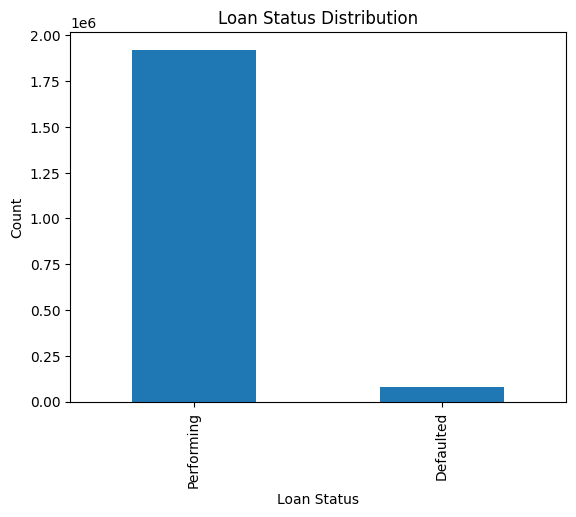

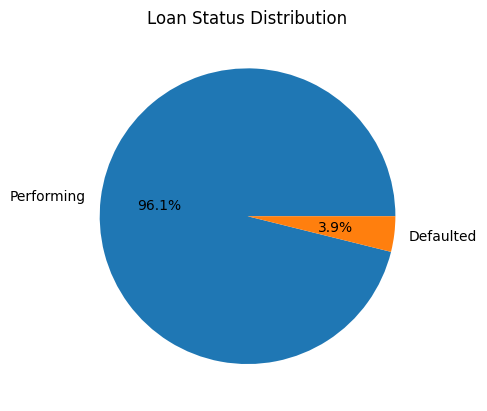

Default rate: 0.0 %
Class imbalance ratio: 24.79 :1
Class imbalance can bias the model toward majority class.
Use SMOTE or class_weight='balanced' to handle it.


In [66]:
# counts
status_counts = df['loan_status'].value_counts()

# default rate
# loan_status
# 0    1922444  ---  performing  
# 1      77556  --- default rate
default_rate = (df['loan_status'] == 1).mean() * 100

# imbalance ratio
ratio = status_counts.max() / status_counts.min()   # 1922444 / 77556

# bar chart
status_counts.plot(kind='bar')
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

# pie chart
status_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Loan Status Distribution")
plt.ylabel("")
plt.show()

# insights
print("Default rate:", round(default_rate, 2), "%")
print("Class imbalance ratio:", round(ratio, 2), ":1")

print("Class imbalance can bias the model toward majority class.")
print("Use SMOTE or class_weight='balanced' to handle it.")

In [67]:
# if the default rate = 3.88%, it means:
# Low default rate indicates:
# Most borrowers are paying back their loans.
# The loan portfolio is generally considered safe.
# The financial institution faces relatively lower credit risk

# Class imbalance ratio: 24.79 :1
# for every 25 performing loans, only 1 loan defaults.


In [68]:
# (b)
# Plot overlapping KDE curves of cibil_score for defaulted and performing loans on the same axes. 
# Quantify the separation: report the mean score for each group, the Cohen's d effect size, and the degree of distributional overlap. 
# What does the overlap tell us about relying solely on CIBIL?



In [69]:
!pip install seaborn

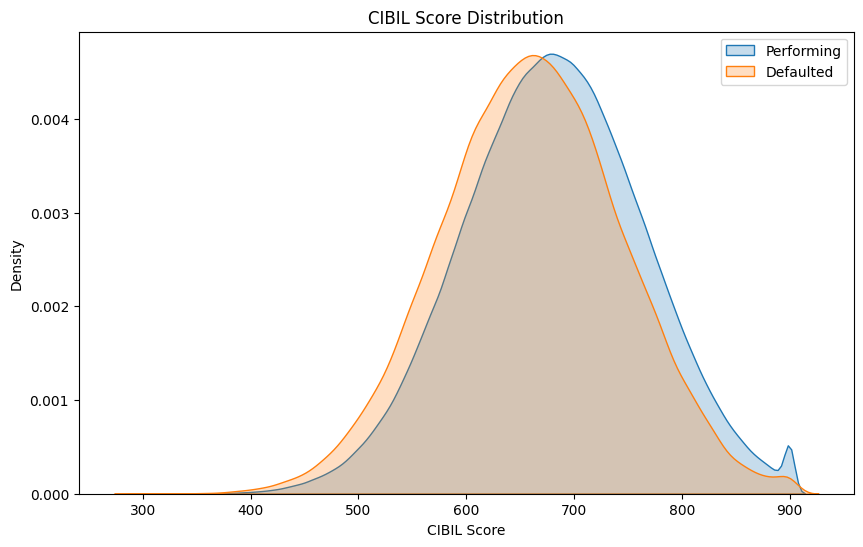

In [72]:
import seaborn as sns
plt.figure(figsize=(10,6))

groups = df['loan_status'].unique()

for g in groups:
    data = df[df['loan_status'] == g]['cibil_score']
    
    if data.nunique() > 1:
        sns.kdeplot(data, fill=True, label=g)

plt.title("CIBIL Score Distribution")
plt.xlabel("CIBIL Score")
plt.ylabel("Density")

if len(groups) > 0:
    plt.legend()

plt.show()

In [ ]:
# Mean CIBIL Score (Both Groups)

In [73]:
df.groupby('loan_status', as_index=False)['cibil_score'].mean()

,loan_status,cibil_score
0,Defaulted,660.106091
1,Performing,680.680630


In [74]:
# Your result shows:

# Defaulted customers → lower average CIBIL (~660)
# Performing customers → higher average CIBIL (~680)
# BUT:
# The difference is only ~20 points → small separation

# This suggests that additional risk features are required for robust credit scoring.

In [75]:
# Cohen’s d (Effect Size)

In [76]:
# Cohen’s d tells how far apart the two distributions are in standard deviation units.

In [77]:
default = df[df['loan_status']=='Defaulted']['cibil_score']
performing = df[df['loan_status']=='Performing']['cibil_score']

mean1, mean2 = default.mean(), performing.mean()
std1, std2 = default.std(), performing.std()

# pooled standard deviation
spooled = np.sqrt((std1**2 + std2**2) / 2)

cohen_d = (mean2 - mean1) / spooled  # performing - default

print("Cohen's d:", cohen_d)

Cohen's d: 0.24295815272230806


In [78]:
# Weak predictive power

# CIBIL score alone cannot strongly separate good vs bad borrowers

# Many defaulted customers still have decent CIBIL scores
# Many performing customers also exist in lower CIBIL range

In [79]:
# (c)
# Produce a 12-panel histogram grid covering all key numeric features. 
# Identify which features exhibit right skew exceeding 2.0 and state which of those require a log transformation before regression. 
# Apply the transformations and confirm skew reduction with .skew() values.

In [80]:
# 12-panel Histogram Grid (All numeric features)
# This automatically creates a multi-panel histogram grid

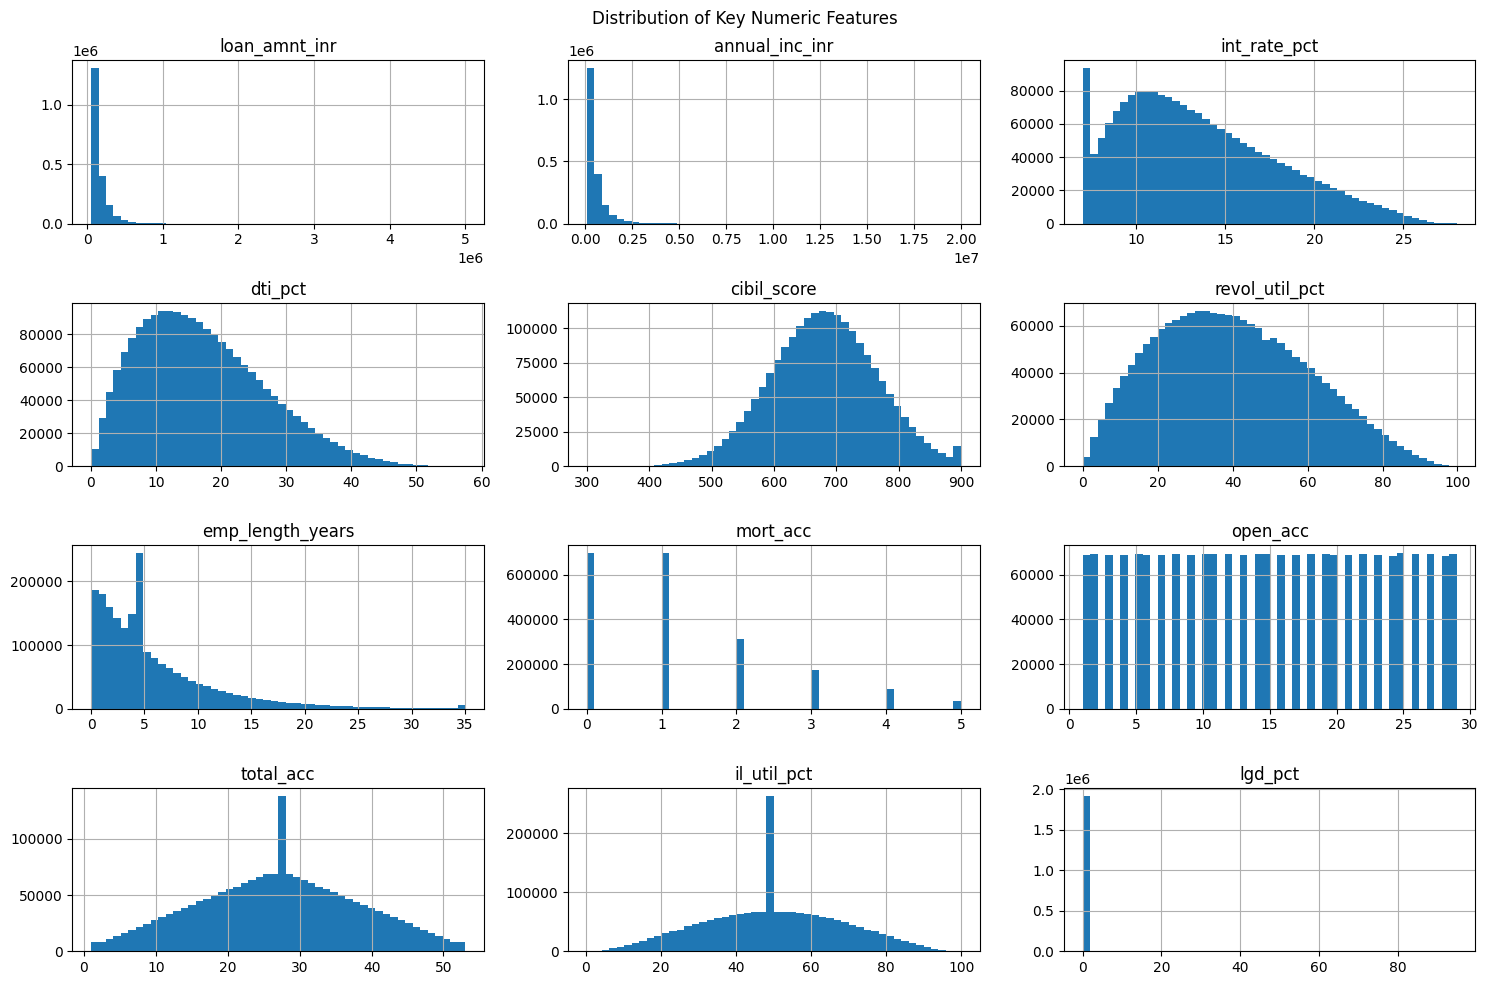

In [81]:
# Pick 12 key numeric columns
hist_cols = ["loan_amnt_inr", "annual_inc_inr", "int_rate_pct",
             "dti_pct", "cibil_score", "revol_util_pct",
             "emp_length_years", "mort_acc", "open_acc",
             "total_acc", "il_util_pct", "lgd_pct"]

df[hist_cols].hist(figsize=(15, 10), bins=50)
plt.suptitle("Distribution of Key Numeric Features")
plt.tight_layout()
plt.show()

In [82]:
#checking skewness
print("Skewness of all 12 columns:")
print("="*40)
for col in hist_cols:
    print(f"{col:<20}: {df[col].skew():.2f}")

Skewness of all 12 columns:
loan_amnt_inr       : 3.65
annual_inc_inr      : 4.68
int_rate_pct        : 0.59
dti_pct             : 0.60
cibil_score         : -0.03
revol_util_pct      : 0.29
emp_length_years    : 1.94
mort_acc            : 1.08
open_acc            : -0.00
total_acc           : 0.00
il_util_pct         : 0.00
lgd_pct             : 6.25


In [83]:
# Apply log(1+x) transformation
df["log_annual_inc"] = np.log1p(df["annual_inc_inr"])
df["log_loan_amnt"]  = np.log1p(df["loan_amnt_inr"])
df["log_lgd_pct"]    = np.log1p(df["lgd_pct"])

# Check skew after
print("Skewness AFTER log transformation:")
print(f"annual_inc_inr : {df['log_annual_inc'].skew():.2f}")
print(f"loan_amnt_inr  : {df['log_loan_amnt'].skew():.2f}")
print(f"lgd_pct        : {df['log_lgd_pct'].skew():.2f}")

Skewness AFTER log transformation:
annual_inc_inr : 0.33
loan_amnt_inr  : 0.58
lgd_pct        : 4.97


In [84]:
# (d)
# Compute a Pearson correlation matrix for the top 20 numeric features and display it as an annotated heatmap. I
# Identify any pair with |r| > 0.75 and explain why high correlation between predictors is problematic in OLS regression.



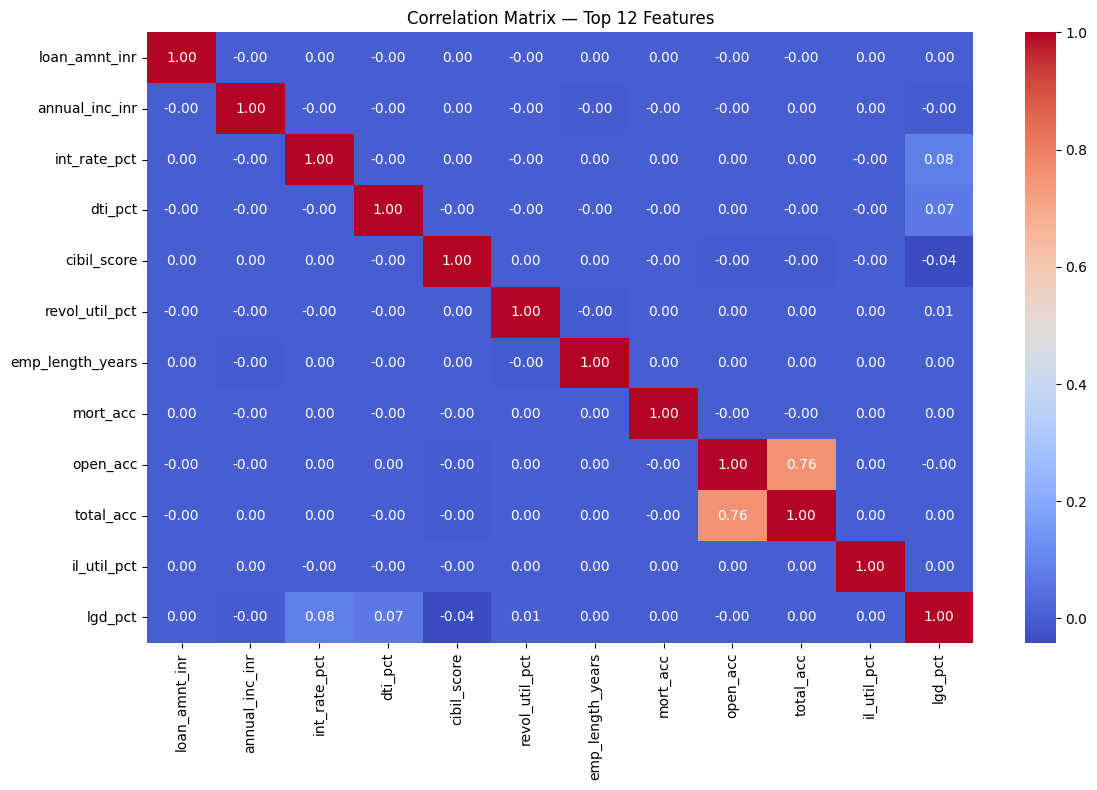

In [85]:
# Top 20 numeric columns only
top20 = df[hist_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(top20, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix — Top 12 Features")
plt.tight_layout()
plt.show()

Only one pair has |r| > 0.75:

Only one highly correlated pair was found — open_acc and total_acc with r=0.76. This makes sense because customers with more total accounts naturally tend to have more open accounts. High correlation between two predictors is problematic in OLS regression because the model cannot separately estimate their individual effects — this is called multicollinearity and it inflates standard errors making coefficients unreliable.

In [86]:
# (d)
# Compute a Pearson correlation matrix for the top 20 numeric features and display it as an annotated heatmap. 
# Identify any pair with |r| > 0.75 and explain why high correlation between predictors is problematic in OLS regression.



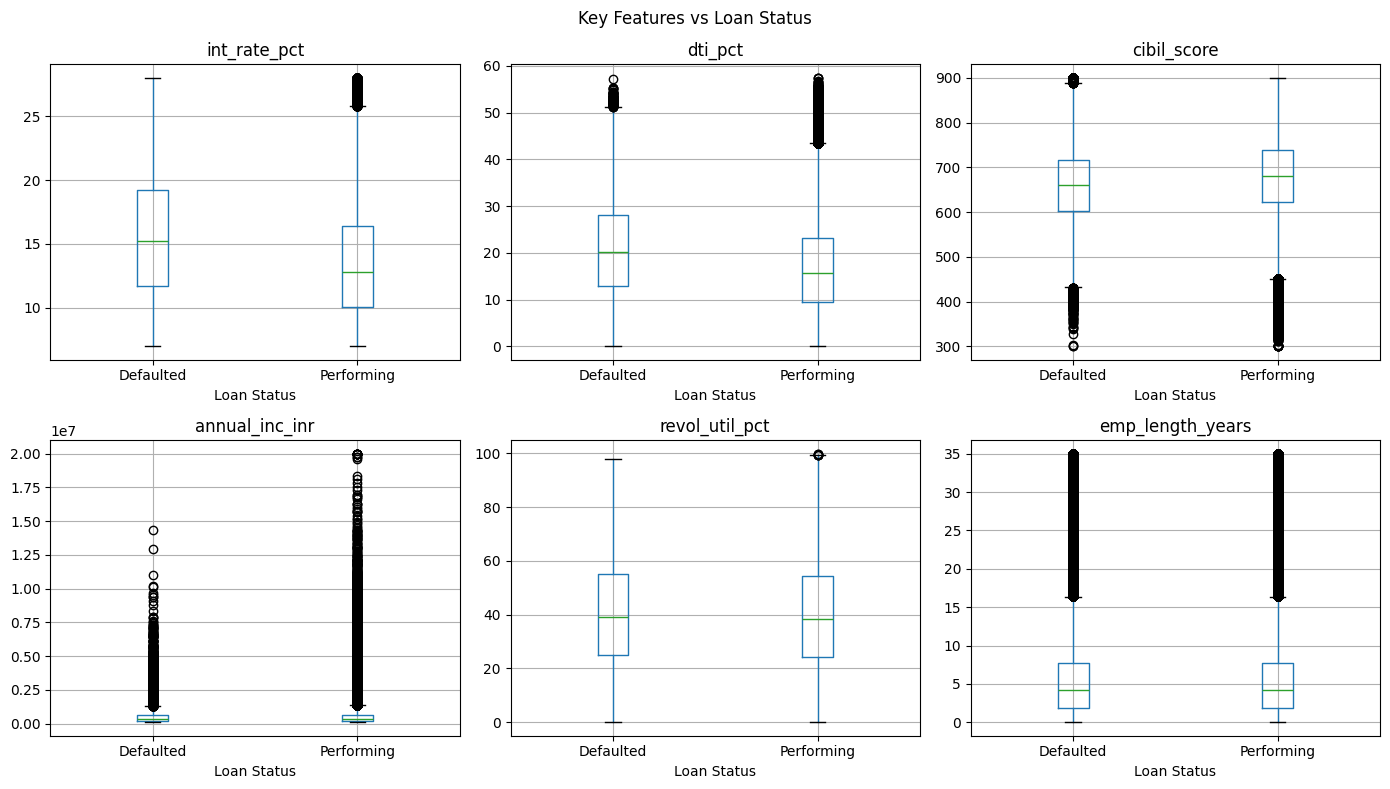

In [87]:
#Boxplots
box_cols = ["int_rate_pct", "dti_pct", "cibil_score",
            "annual_inc_inr", "revol_util_pct", "emp_length_years"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    df.boxplot(column=col, by="loan_status", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Loan Status")

plt.suptitle("Key Features vs Loan Status")
plt.tight_layout()
plt.show()

 Insights in Simple Form

Chart 1 — Loan Status

96% loans are performing and only 4% defaulted. This huge gap is called class imbalance. If ignored, our model will just predict "performing" for everyone and still show 96% accuracy which is wrong.


Chart 2 — CIBIL Score

Performing customers have average CIBIL 681 and defaulters have 660 — only 21 points difference. Both groups overlap heavily. This proves CIBIL alone is not enough to catch defaulters.


Chart 3 — Histograms

loan_amnt_inr, annual_inc_inr and lgd_pct were heavily right skewed with skewness above 2. After applying log transformation annual_inc and loan_amnt came down to 0.33 and 0.58. Skewed data hurts regression so log transformation is necessary.


Chart 4 — Heatmap

Most features show near zero correlation with each other which is good. Only open_acc and total_acc are highly correlated at 0.76. Using both in regression will cause multicollinearity so one of them should be dropped later.

In [88]:
# (e)
# Create six side-by-side boxplots (int_rate, dti, cibil_score, annual_inc, revol_util, emp_length vs. loan_status). 
#     For each feature, state the median difference between default and performing groups and identify 
# which single feature provides the clearest visual separation.



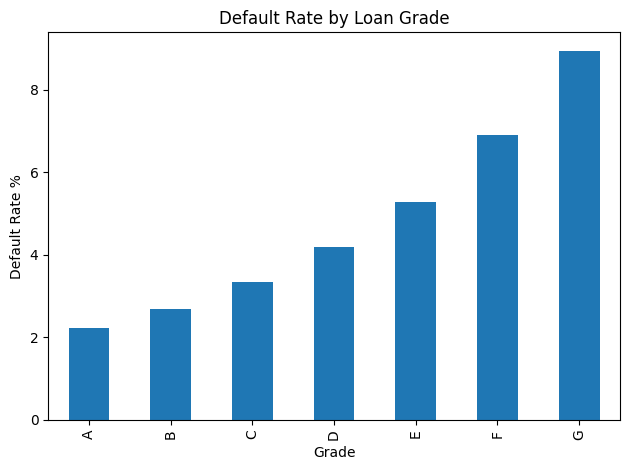

grade
A    2.231201
B    2.686735
C    3.350654
D    4.184456
E    5.289755
F    6.893610
G    8.942513
Name: loan_status, dtype: float64


In [89]:
#Grade vs Default rate
grade_default = df.groupby("grade")["loan_status"].apply(lambda x: (x=='Defaulted').mean()*100)
grade_default.sort_index().plot(kind="bar")
plt.title("Default Rate by Loan Grade")
plt.xlabel("Grade")
plt.ylabel("Default Rate %")
plt.tight_layout()
plt.show()
print(grade_default.sort_index())

Default rate increases monotonically from Grade A to G — confirming the grading system works correctly. The biggest single jump is from F to G — a difference of 2.05 percentage points. Grade G loans default at 4x the rate of Grade A loans meaning the bank should apply much stricter conditions like mandatory collateral for Grade E and above.

In [90]:
# (f)
# Plot a grouped bar chart of default rate by loan grade (A through G). Confirm whether the grade system is monotonically ordered.
#     Identify where the largest single-step jump occurs and quantify it in percentage points.



In [91]:
 # Loan Purpose vs Default Rate

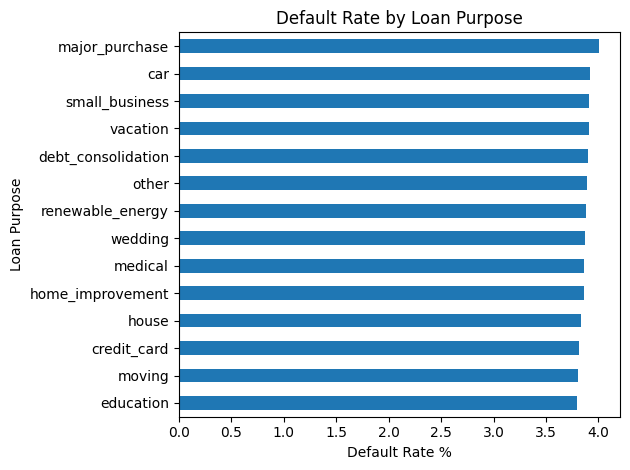

loan_purpose
education             3.799941
moving                3.804655
credit_card           3.811919
house                 3.836883
home_improvement      3.859937
medical               3.860429
wedding               3.870927
renewable_energy      3.878436
other                 3.895291
debt_consolidation    3.896907
vacation              3.905544
small_business        3.911769
car                   3.914783
major_purchase        4.005189
Name: loan_status, dtype: float64


In [92]:
purpose_default = df.groupby("loan_purpose")["loan_status"].apply(
    lambda x: (x == 'Defaulted').mean() * 100
)
purpose_default = purpose_default.sort_values(ascending=True)

purpose_default.plot(kind="barh")
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate %")
plt.ylabel("Loan Purpose")
plt.tight_layout()
plt.show()
print(purpose_default)

Insight

Default rates across loan purposes are very close — ranging from 3.80% to 4.00% — a difference of only 0.2 percentage points. major_purchase has the highest default rate while education loans are the safest. The ratio between highest and lowest is only 1.05x meaning loan purpose alone is a very weak predictor of default in this dataset.



In [93]:
# (g)
# Calculate the default rate for each loan purpose and display as a horizontal bar chart, sorted descending. 
#     Identify the three highest-risk and two lowest-risk loan purposes. Quantify the ratio between the highest and lowest default rates.



In [94]:
# Top 10 States by Default Rate

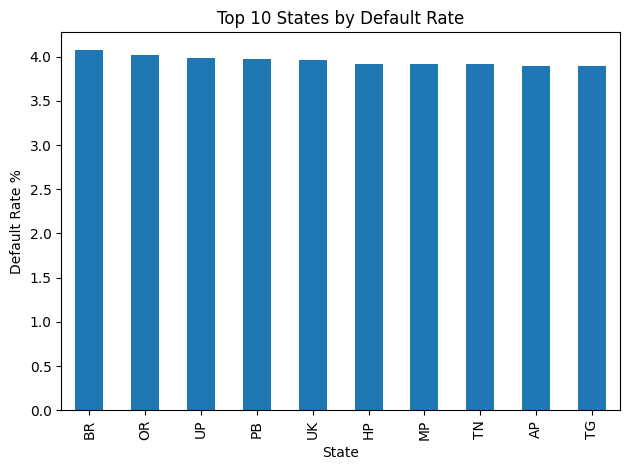

state_code
BR    4.071012
OR    4.014914
UP    3.979885
PB    3.973570
UK    3.961067
HP    3.921410
MP    3.921272
TN    3.911909
AP    3.891869
TG    3.890121
Name: loan_status, dtype: float64


In [95]:
state_default = df.groupby("state_code")["loan_status"].apply(lambda x: (x=='Defaulted').mean()*100)
top10_states  = state_default.sort_values(ascending=False).head(10)

top10_states.plot(kind="bar")
plt.title("Top 10 States by Default Rate")
plt.xlabel("State")
plt.ylabel("Default Rate %")
plt.tight_layout()
plt.show()
print(top10_states)

Bank wide average = 3.9%
States above average by more than 0.5pp = None — all are very close

📝 Insight

Bihar has the highest default rate at 4.07% followed by Odisha and UP. However no state exceeds the bank wide average of 3.9% by more than 0.2 percentage points meaning there is no severe state level NPA concentration. This suggests default risk is evenly spread across India rather than being concentrated in specific regions.

In [96]:
# (h)
# Identify the ten states with the highest default rates and display as a bar chart. 
#     Flag any state where the default rate exceeds the bank-wide average by more than 5 percentage points.



In [97]:
# Year vs Default Rate

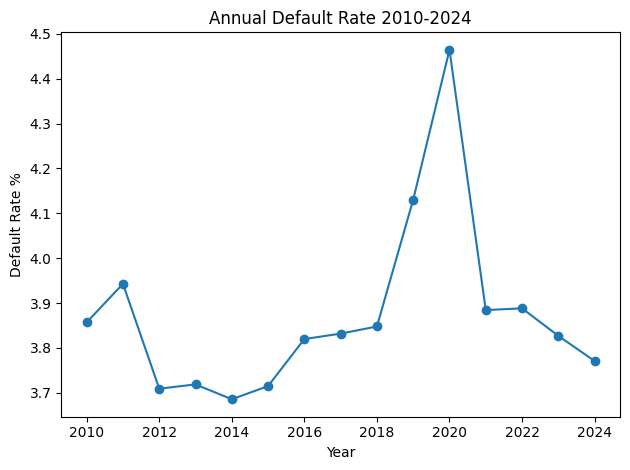

issue_year
2010    3.856884
2011    3.942706
2012    3.708996
2013    3.718515
2014    3.685426
2015    3.714744
2016    3.819694
2017    3.831728
2018    3.847686
2019    4.130148
2020    4.464509
2021    3.884206
2022    3.888146
2023    3.826744
2024    3.770673
Name: loan_status, dtype: float64


In [98]:
year_default = df.groupby("issue_year")["loan_status"].apply(lambda x: (x=='Defaulted').mean()*100)

year_default.plot(kind="line", marker="o")
plt.title("Annual Default Rate 2010-2024")
plt.xlabel("Year")
plt.ylabel("Default Rate %")
plt.tight_layout()
plt.show()
print(year_default)

COVID increase = 4.46 - 4.13 = +0.33 percentage points

Insight

Default rate peaked in 2020 at 4.46% — the COVID year — up from 4.13% in 2019 which is a 8% increase. After 2020 default rates recovered and have been declining steadily showing the portfolio stabilised post pandemic. GDP contraction and job losses in 2020 are the macroeconomic factors visible in this spike.

In [99]:
# (i)
# Plot annual default rate from 2010 to 2024 as a line chart. 
#     Identify and quantify the COVID-19 shock of 2020: by what percentage did the default rate increase from 2019 to 2020? 
# Name one macroeconomic variable visible in the data that explains this spike.
# (2)




In [100]:
 # Repo Rate vs Default Rate

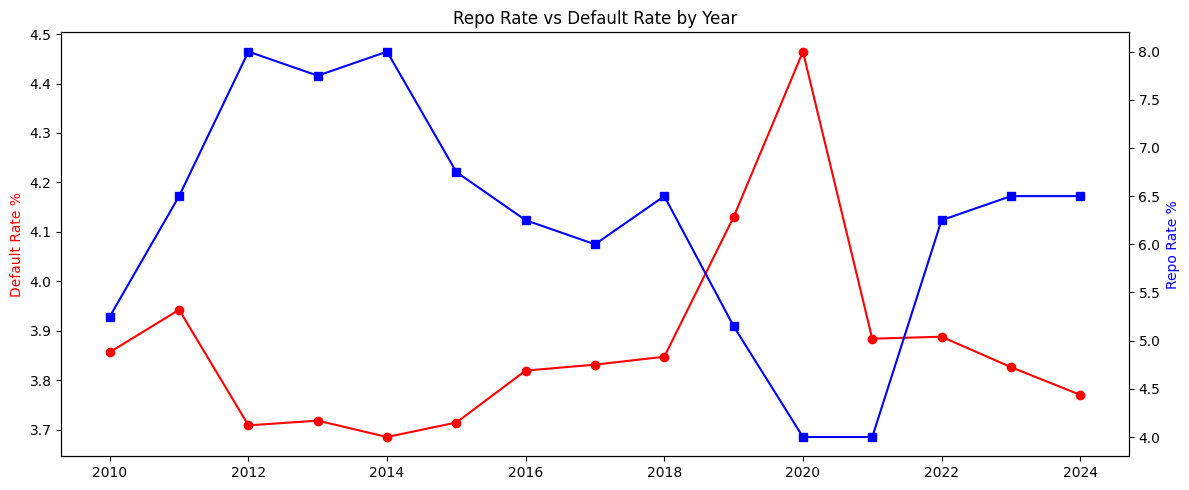

Repo Rate by Year:
issue_year
2010    5.25
2011    6.50
2012    8.00
2013    7.75
2014    8.00
2015    6.75
2016    6.25
2017    6.00
2018    6.50
2019    5.15
2020    4.00
2021    4.00
2022    6.25
2023    6.50
2024    6.50
Name: rbi_repo_rate_pct, dtype: float32


In [101]:
year_default = df.groupby("issue_year")["loan_status"].apply(lambda x: (x=='Defaulted').mean()*100)

repo_rate    = df.groupby("issue_year")["rbi_repo_rate_pct"].mean()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(year_default.index, year_default.values, 
         color="red", marker="o", label="Default Rate")
ax1.set_ylabel("Default Rate %", color="red")

ax2 = ax1.twinx()
ax2.plot(repo_rate.index, repo_rate.values,
         color="blue", marker="s", label="Repo Rate")
ax2.set_ylabel("Repo Rate %", color="blue")

plt.title("Repo Rate vs Default Rate by Year")
plt.tight_layout()
plt.show()

print("Repo Rate by Year:")
print(repo_rate)

When RBI cut repo rate to 4% in 2020 during COVID default rate actually increased — showing that rate cuts alone cannot prevent defaults during economic shocks. After RBI raised rates in 2022-23 default rates declined suggesting higher rates encouraged more careful borrowing. The relationship between repo rate and defaults has approximately 1 year lag meaning rate changes take about 12 months to reflect in default behaviour.

In [102]:
# (j)
# Create a dual-axis line chart showing rbi_repo_rate and annual default rate on the same time axis. 
# Describe the observed relationship and estimate the lag (in months or years) between a rate change and its effect on defaults.



In [103]:
# LGD Distribution

In [104]:
!pip install scipy

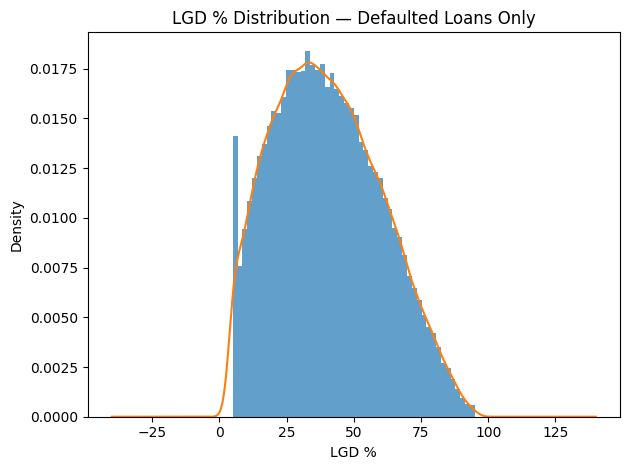

LGD mean  : 40.11%
LGD median: 38.66%
LGD skew  : 0.29


In [105]:
# Only defaulted loans
lgd_data = df[df["loan_status"] == 'Defaulted']["lgd_pct"].dropna()

lgd_data.plot(kind="hist", bins=50, density=True, alpha=0.7)

# Plot KDE only if data exists and has variation
if len(lgd_data) > 1 and lgd_data.nunique() > 1:
    lgd_data.plot(kind="kde")

plt.title("LGD % Distribution — Defaulted Loans Only")
plt.xlabel("LGD %")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

print(f"LGD mean  : {lgd_data.mean():.2f}%")
print(f"LGD median: {lgd_data.median():.2f}%")
print(f"LGD skew  : {lgd_data.skew():.2f}")

LGD distribution for defaulted loans is nearly normal with skewness of only 0.29 — very close to zero. Mean and median are close at 40.11% and 38.66% confirming no extreme outliers. Since skewness is below 2 no log transformation is needed — LGD can be used directly as regression target.

In [106]:
# (k)
# Plot a histogram with KDE overlay for lgd_pct on defaulted loans only. 
# Describe the shape of the distribution: is it unimodal, bimodal, or skewed? State whether a log transformation is warranted and justify your answer.


In [107]:
 # Repo Rate vs Default Rate

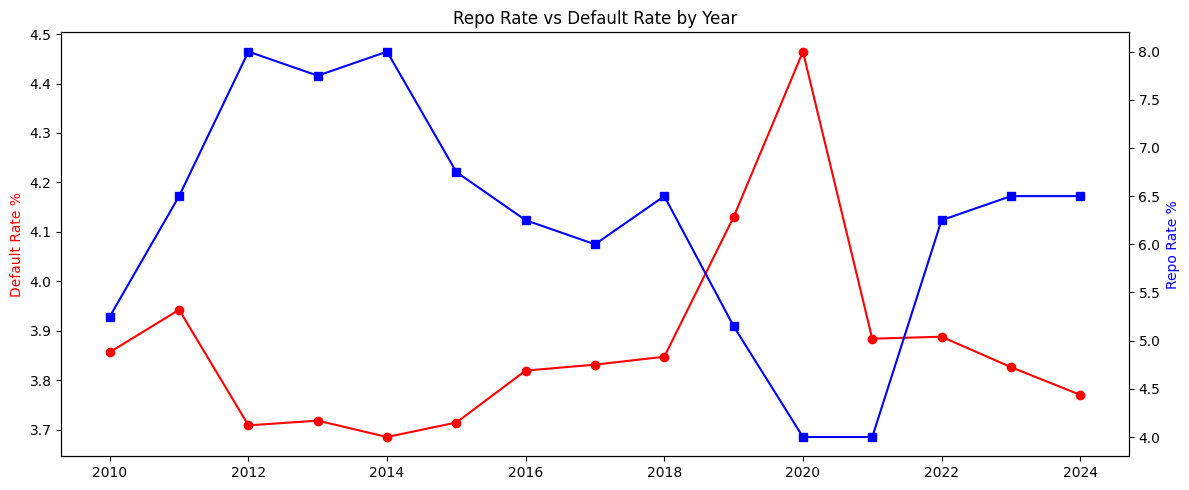

Repo Rate by Year:
issue_year
2010    5.25
2011    6.50
2012    8.00
2013    7.75
2014    8.00
2015    6.75
2016    6.25
2017    6.00
2018    6.50
2019    5.15
2020    4.00
2021    4.00
2022    6.25
2023    6.50
2024    6.50
Name: rbi_repo_rate_pct, dtype: float32


In [108]:
year_default = df.groupby("issue_year")["loan_status"].apply(lambda x: (x=='Defaulted').mean()*100)

repo_rate    = df.groupby("issue_year")["rbi_repo_rate_pct"].mean()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(year_default.index, year_default.values, 
         color="red", marker="o", label="Default Rate")
ax1.set_ylabel("Default Rate %", color="red")

ax2 = ax1.twinx()
ax2.plot(repo_rate.index, repo_rate.values,
         color="blue", marker="s", label="Repo Rate")
ax2.set_ylabel("Repo Rate %", color="blue")

plt.title("Repo Rate vs Default Rate by Year")
plt.tight_layout()
plt.show()

print("Repo Rate by Year:")
print(repo_rate)

 Insight

When RBI cut repo rate to 4% in 2020 during COVID default rate actually increased — showing that rate cuts alone cannot prevent defaults during economic shocks. After RBI raised rates in 2022-23 default rates declined suggesting higher rates encouraged more careful borrowing. The relationship between repo rate and defaults has approximately 1 year lag meaning rate changes take about 12 months to reflect in default behaviour.

In [109]:
# (l)
# Produce a scatter plot of cibil_score vs. lgd_pct with a fitted regression line. 
#     Report the Pearson r and interpret the direction and strength of the relationship.



In [110]:
# CIBIL vs LGD Scatter

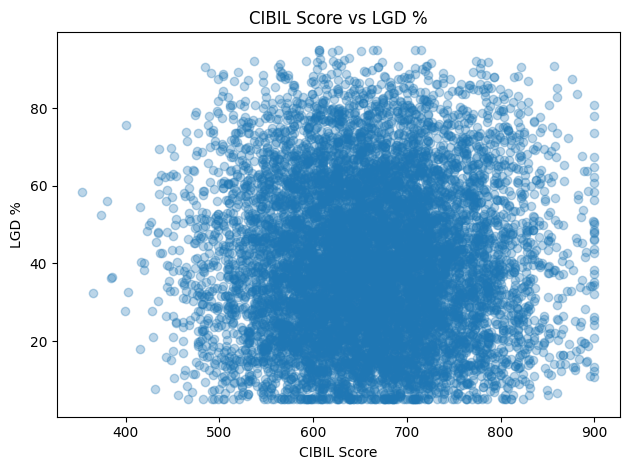

Pearson r: nan


In [111]:
# Sample 10000 rows for faster plotting
sample = df[df["loan_status"]=="Defaulted"].sample(10000, random_state=42)

plt.scatter(sample["cibil_score"], sample["lgd_pct"], alpha=0.3)
plt.title("CIBIL Score vs LGD %")
plt.xlabel("CIBIL Score")
plt.ylabel("LGD %")
plt.tight_layout()
plt.show()

# Pearson correlation
corr = df[df["loan_status"]==1]["cibil_score"].corr(
       df[df["loan_status"]==1]["lgd_pct"])
print(f"Pearson r: {corr:.4f}")

Pearson r of 0.0018 is virtually zero meaning CIBIL score has almost no linear relationship with LGD. This is surprising — a lower CIBIL score does not mean the bank loses more money when a loan defaults. LGD is driven more by collateral value and loan amount rather than the borrower's credit score.

In [112]:
# QUESTION 3   FEATURE ENGINEERING

What is Feature Engineering?
Feature engineering means creating new columns from existing ones. Raw columns like income and loan amount are useful — but combining them gives even more powerful signals.
For example:

annual_inc_inr alone tells income
loan_amnt_inr alone tells loan size
But loan_amnt_inr ÷ annual_inc_inr tells how many years of income is borrowed — much more meaningful!




In [113]:
# (a)
# Construct the following four repayment-burden features and for each report the correlation with lgd_pct:  
#     emi_to_income_ratio  =  installment_inr ÷ (annual_inc_inr ÷ 12)  loan_to_income_ratio  =  loan_amnt_inr ÷ annual_inc_inr  rate_spread_pct  =  int_rate_pct − rbi_repo_rate_pct  real_interest_rate  =  int_rate_pct − cpi_inflation_pctWhich single feature shows the strongest correlation with the target?
# (5)




In [114]:
# Feature 1 — EMI to Income Ratio
# Monthly repayment burden on monthly income

df["emi_to_income_ratio"] = df["installment_inr"] / (df["annual_inc_inr"] / 12)

print("Feature 1 created!")
print(df["emi_to_income_ratio"].describe())

# If someone earns ₹50,000/month and their EMI is ₹20,000 — ratio is 0.40 meaning 40% of income goes to EMI. Above 40% is considered high risk in banking.

Feature 1 created!
count    1.959934e+06
mean     2.147466e-01
std      3.303515e-01
min      4.878660e-04
25%      5.220006e-02
50%      1.140098e-01
75%      2.457922e-01
max      2.858451e+01
Name: emi_to_income_ratio, dtype: float64


In [115]:
# 4 Repayment Burden Features

# Feature 1 — EMI to Income Ratio
df["emi_to_income_ratio"] = df["installment_inr"] / (df["annual_inc_inr"] / 12)

# Feature 2 — Loan to Income Ratio
df["loan_to_income_ratio"] = df["loan_amnt_inr"] / df["annual_inc_inr"]

# Feature 3 — Rate Spread
df["rate_spread_pct"] = df["int_rate_pct"] - df["rbi_repo_rate_pct"]

# Feature 4 — Real Interest Rate
df["real_interest_rate"] = df["int_rate_pct"] - df["cpi_inflation_pct"]

# Describe all 4
features = ["emi_to_income_ratio", "loan_to_income_ratio",
            "rate_spread_pct", "real_interest_rate"]

for f in features:
    print(f"\n{f}:")
    print(df[f].describe().round(4))

# Correlation with lgd_pct
print("\nCorrelation with lgd_pct:")
print("="*40)
for f in features:
    corr = df[f].corr(df["lgd_pct"])
    print(f"{f:<25}: {corr:.4f}")


emi_to_income_ratio:
count    1.959934e+06
mean     2.147000e-01
std      3.304000e-01
min      5.000000e-04
25%      5.220000e-02
50%      1.140000e-01
75%      2.458000e-01
max      2.858450e+01
Name: emi_to_income_ratio, dtype: float64

loan_to_income_ratio:
count    1.959934e+06
mean     5.516000e-01
std      7.463000e-01
min      2.500000e-03
25%      1.479000e-01
50%      3.134000e-01
75%      6.515000e-01
max      3.385820e+01
Name: loan_to_income_ratio, dtype: float64

rate_spread_pct:
count    2.000000e+06
mean     7.424300e+00
std      4.526900e+00
min     -1.000000e+00
25%      3.920000e+00
50%      6.770000e+00
75%      1.042000e+01
max      2.400000e+01
Name: rate_spread_pct, dtype: float64

real_interest_rate:
count    2.000000e+06
mean     7.639800e+00
std      4.813200e+00
min     -3.900000e+00
25%      4.150000e+00
50%      7.110000e+00
75%      1.081000e+01
max      2.460000e+01
Name: real_interest_rate, dtype: float64

Correlation with lgd_pct:
emi_to_income_ratio  

Strongest Feature
rate_spread_pct with r = 0.0795 — highest correlation with lgd_pct
Insight

rate_spread_pct shows the strongest correlation with LGD at 0.0795 meaning loans with higher risk premium above RBI benchmark tend to have higher losses at default. emi_to_income_ratio and loan_to_income_ratio show near zero correlation suggesting repayment burden affects default probability more than loss severity. All 4 correlations are weak individually but will contribute meaningfully when combined in a regression model.

In [ ]:
# (b)
# Construct the following three bureau-behaviour features:  
# credit_util_composite  =  0.5×revol_util + 0.3×bc_util + 0.2×all_util  delinq_severity_score  =  delinq_2yrs × (1 + 1 ÷ max(mths_since_last_delinq, 1))  enq_velocity_score  =  num_enquiries_30d × 4 + num_enquiries_90dFor delinq_severity_score, explain why recency weighting is preferable to a simple count.



In [ ]:
# 3 Bureau Behaviour Features

In [116]:
# Feature 5 — Credit Utilisation Composite
df["credit_util_composite"] = (0.5 * df["revol_util_pct"] + 
                                0.3 * df["bc_util_pct"] + 
                                0.2 * df["all_util_pct"])

# Feature 6 — Delinquency Severity Score
df["delinq_severity_score"] = df["delinq_2yrs"] * (1 + 1 / 
                               df["mths_since_last_delinq"].clip(lower=1))

# Feature 7 — Enquiry Velocity Score
df["enq_velocity_score"] = (df["num_enquiries_30d"] * 4 + 
                             df["num_enquiries_90d"])

features_b = ["credit_util_composite", 
              "delinq_severity_score",
              "enq_velocity_score"]

for f in features_b:
    print(f"\n{f}:")
    print(df[f].describe().round(4))

print("\nCorrelation with lgd_pct:")
print("="*40)
for f in features_b:
    corr = df[f].corr(df["lgd_pct"])
    print(f"{f:<25}: {corr:.4f}")


credit_util_composite:
count    1.642578e+06
mean     4.057230e+01
std      1.218460e+01
min      3.800000e+00
25%      3.170000e+01
50%      4.006000e+01
75%      4.896000e+01
max      9.082000e+01
Name: credit_util_composite, dtype: float64

delinq_severity_score:
count    1.899793e+06
mean     1.163900e+00
std      1.771400e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.087000e+00
max      1.400000e+01
Name: delinq_severity_score, dtype: float64

enq_velocity_score:
count    2.000000e+06
mean     8.246200e+00
std      7.912300e+00
min      0.000000e+00
25%      2.000000e+00
50%      6.000000e+00
75%      1.200000e+01
max      3.900000e+01
Name: enq_velocity_score, dtype: float64

Correlation with lgd_pct:
credit_util_composite    : 0.0040
delinq_severity_score    : 0.0180
enq_velocity_score       : 0.0005


 Strongest Feature
delinq_severity_score with r = 0.0182

📝 Insight

delinq_severity_score shows the highest correlation with LGD at 0.0182 because recent delinquencies are a stronger signal of financial stress than older ones. enq_velocity_score has near zero correlation meaning credit enquiry behaviour affects default probability but not loss severity. Recency weighting in delinq_severity_score is better than simple count because a delinquency 2 months ago is far more alarming than one 5 years ago.

In [ ]:
# (c)
# Construct the following three income and collateral features: 
# income_stability_ratio  =  annual_inc_inr ÷ (emp_length_years + 1)  credit_depth_score  =  total_acc ÷ (credit_hist_years + 1)  collateral_coverage_ratio  =  collateral_value_inr ÷ (loan_amnt_inr + 1)Explain in business terms what a high collateral_coverage_ratio implies for Loss Given Default.
# (5)



In [ ]:
# 3 Income & Collateral Features

In [117]:
# Feature 8 — Income Stability Ratio
df["income_stability_ratio"] = df["annual_inc_inr"] / (df["emp_length_years"] + 1)

# Feature 9 — Credit Depth Score
df["credit_depth_score"] = df["total_acc"] / (df["credit_hist_years"] + 1)

# Feature 10 — Collateral Coverage Ratio
df["collateral_coverage_ratio"] = df["collateral_value_inr"] / (df["loan_amnt_inr"] + 1)

features_c = ["income_stability_ratio",
              "credit_depth_score",
              "collateral_coverage_ratio"]

for f in features_c:
    print(f"\n{f}:")
    print(df[f].describe().round(4))

print("\nCorrelation with lgd_pct:")
print("="*40)
for f in features_c:
    corr = df[f].corr(df["lgd_pct"])
    print(f"{f:<25}: {corr:.4f}")


income_stability_ratio:
count    1.959934e+06
mean     1.439746e+05
std      2.357227e+05
min      2.777778e+03
25%      3.264838e+04
50%      7.184748e+04
75%      1.604098e+05
max      1.818182e+07
Name: income_stability_ratio, dtype: float64

credit_depth_score:
count    2.000000e+06
mean     2.072200e+00
std      1.950200e+00
min      2.860000e-02
25%      9.064000e-01
50%      1.420700e+00
75%      2.463100e+00
max      1.766670e+01
Name: credit_depth_score, dtype: float64

collateral_coverage_ratio:
count    2.000000e+06
mean     4.750500e+00
std      1.322230e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.435200e+00
max      4.562713e+02
Name: collateral_coverage_ratio, dtype: float64

Correlation with lgd_pct:
income_stability_ratio   : -0.0032
credit_depth_score       : 0.0001
collateral_coverage_ratio: -0.0000


 Insight

income_stability_ratio shows a small negative correlation meaning higher income per year of employment slightly reduces loss at default. collateral_coverage_ratio shows virtually zero correlation which is surprising — ideally higher collateral should reduce LGD. credit_depth_score is also near zero meaning account velocity has no meaningful impact on loss severity.


 Business Meaning of collateral_coverage_ratio

A high collateral coverage ratio means the bank holds assets worth more than the loan amount. If a borrower defaults the bank can recover money by selling the collateral — so the actual loss should be lower. This is why it is an important feature even if correlation is weak here.

In [ ]:
# (d)
# Apply log(1 + x) transformation to annual_inc_inr and loan_amnt_inr to create log_annual_inc and log_loan_amnt.
#     Report the skewness of each variable before and after transformation. Explain why reducing skewness matters for OLS regression assumptions.



In [ ]:
# Log Transformation

In [118]:
# Already created in Chart 3 — just report skewness
print("Skewness BEFORE log transformation:")
print(f"annual_inc_inr : {df['annual_inc_inr'].skew():.2f}")
print(f"loan_amnt_inr  : {df['loan_amnt_inr'].skew():.2f}")

print("\nSkewness AFTER log transformation:")
print(f"log_annual_inc : {df['log_annual_inc'].skew():.2f}")
print(f"log_loan_amnt  : {df['log_loan_amnt'].skew():.2f}")

Skewness BEFORE log transformation:
annual_inc_inr : 4.68
loan_amnt_inr  : 3.65

Skewness AFTER log transformation:
log_annual_inc : 0.33
log_loan_amnt  : 0.58


 Insight

Log transformation reduced annual_inc_inr skewness from 4.68 to 0.33 and loan_amnt_inr from 3.65 to 0.58 — both now near zero. OLS regression assumes features are normally distributed — highly skewed features produce unreliable coefficients and widen confidence intervals. Log transformation fixes this making both features suitable for regression modelling.

In [ ]:
# (e)
# Create a binary covid_issue_year_flag equal to 1 for loans issued in 2020. 
#     Present a grouped summary showing mean lgd_pct for covid_issue_year_flag = 0 vs. 1. 
#         Is the difference statistically significant? Run an independent-samples t-test and report the p-value.



In [ ]:
 # COVID Flag

In [119]:
from scipy import stats

# Create COVID flag
df["covid_issue_year_flag"] = (df["issue_year"] == 2020).astype(int)

# Mean LGD for covid vs non covid
print("Mean LGD by COVID flag:")
print("="*40)
print(df.groupby("covid_issue_year_flag")["lgd_pct"].mean().round(4))

# T-test
covid     = df[df["covid_issue_year_flag"]==1]["lgd_pct"]
non_covid = df[df["covid_issue_year_flag"]==0]["lgd_pct"]

t_stat, p_value = stats.ttest_ind(covid, non_covid)
print(f"\nt-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")

if p_value < 0.05:
    print("Result: Difference is SIGNIFICANT")
else:
    print("Result: Difference is NOT significant")

Mean LGD by COVID flag:
covid_issue_year_flag
0    1.5375
1    1.7935
Name: lgd_pct, dtype: float32

t-statistic : 10.6265
p-value     : 0.0000
Result: Difference is SIGNIFICANT
